Found temperatures: ['300K', '600K', '900K', '1200K']

Processing 300K...
  300K: averaged 15 windows, 10001 steps each
Processing 600K...
  600K: averaged 15 windows, 10001 steps each
Processing 900K...
  900K: averaged 15 windows, 10001 steps each
Processing 1200K...
  1200K: averaged 15 windows, 10001 steps each

Data saved to 'pdos_multiorigin_combined.csv'


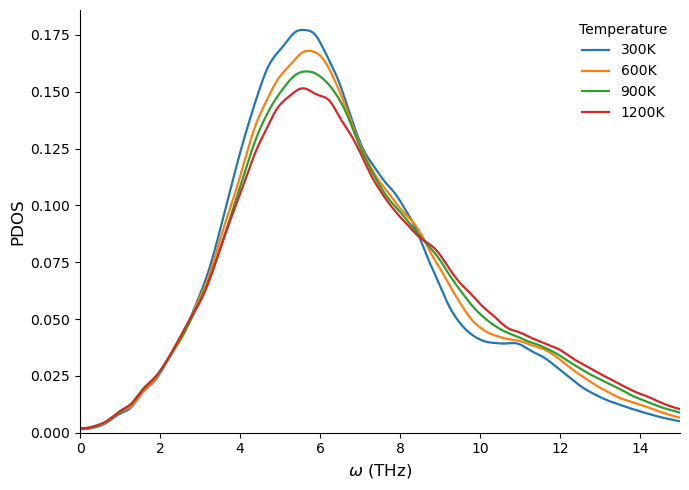

Figure saved to 'pdos_temperature_comparison.png'


In [4]:
"""
PDOS post-processing from multi-window LAMMPS compute-vacf output
(300K-partial-vacf-win1.dat, win2.dat, ... as written by the updated PDOS_mod.in)

Each window file is a single-origin VACF, in the same 6-column format you
used originally (timestep + 5 element columns). Averaging N_WINDOWS of these
together gives a multi-origin-averaged VACF -- the actual noise reduction --
without ever writing a per-atom velocity trajectory to disk.
"""

import glob
import re
import numpy as np
import pandas as pd
from scipy.fft import dct
from scipy.ndimage import gaussian_filter1d

_trapz = getattr(np, "trapezoid", None) or np.trapz  # numpy >=2.0 renamed trapz -> trapezoid

# ------------------------ USER SETTINGS ------------------------------
dt_ps            = 0.001      # LAMMPS timestep
elements         = ["Fe", "Ni", "Cr", "Co", "Al"]
atomic_fractions = {"Fe": 0.2, "Ni": 0.2, "Cr": 0.2, "Co": 0.2, "Al": 0.1}  # <-- set to your real composition
zero_pad_factor  = 8
window_type      = "exponential"   # "hann" or "exponential"
exp_decay_ps     = 3.0
smoothing_sigma_THz = 0.15
freq_max_THz     = 15.0
output_csv       = "pdos_multiorigin_combined.csv"


def read_vacf_window(path):
    """Returns dict element -> 1D vacf array (length = steps in that window)."""
    with open(path, "r") as f:
        lines = f.readlines()
    rows = []
    for line in lines:
        if line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) == 6:
            rows.append([float(x) for x in parts])
    data = np.array(rows)
    return {el: data[:, i + 1] for i, el in enumerate(elements)}


def multi_origin_average(temp_label):
    """Average every window file for this temperature -> one VACF per element."""
    win_files = sorted(
        glob.glob(f"{temp_label}-partial-vacf-win*.dat"),
        key=lambda x: int(re.search(r"win(\d+)", x).group(1)),
    )
    if not win_files:
        raise ValueError(f"No window files found for {temp_label}")

    per_window = [read_vacf_window(f) for f in win_files]
    min_len = min(len(w[elements[0]]) for w in per_window)  # in case a window is short

    averaged = {}
    for el in elements:
        stacked = np.stack([w[el][:min_len] for w in per_window])
        vacf = stacked.mean(axis=0)
        averaged[el] = vacf / vacf[0]   # normalize VACF(0) = 1
    print(f"  {temp_label}: averaged {len(win_files)} windows, {min_len} steps each")
    return averaged


def apply_window(vacf, dt_ps):
    n = len(vacf)
    if window_type == "hann":
        w = np.hanning(2 * n)[n:]
    else:
        t = np.arange(n) * dt_ps
        w = np.exp(-t / exp_decay_ps)
    return vacf * w


def vacf_to_pdos(vacf, dt_ps, n_pad):
    spectrum = dct(vacf, type=1, n=n_pad)
    spectrum = np.clip(spectrum, 0, None)
    freqs_thz = np.fft.rfftfreq(2 * (n_pad - 1), d=dt_ps * 1e-12) / 1e12
    freqs_thz = freqs_thz[: len(spectrum)]
    return freqs_thz, spectrum


def process_temperature(temp_label):
    print(f"Processing {temp_label}...")
    vacf_by_element = multi_origin_average(temp_label)

    n_pad = None
    total_pdos = None
    freqs = None

    for el in elements:
        vacf_w = apply_window(vacf_by_element[el], dt_ps)
        if n_pad is None:
            n_pad = zero_pad_factor * len(vacf_w)
        f_thz, spec = vacf_to_pdos(vacf_w, dt_ps, n_pad)

        if total_pdos is None:
            total_pdos = np.zeros_like(spec)
            freqs = f_thz
        total_pdos += spec * atomic_fractions[el]

    total_pdos = total_pdos / _trapz(total_pdos, freqs)

    freq_resolution = freqs[1] - freqs[0]
    sigma_idx = smoothing_sigma_THz / freq_resolution
    total_pdos_smoothed = gaussian_filter1d(total_pdos, sigma=sigma_idx)

    return freqs, total_pdos_smoothed


def main():
    win_files = glob.glob("*K-partial-vacf-win*.dat")
    if not win_files:
        raise ValueError("No window files found! Expected e.g. '300K-partial-vacf-win1.dat'.")
    temp_labels = sorted(
        set(re.search(r"(\d+K)-partial-vacf-win", f).group(1) for f in win_files),
        key=lambda x: int(x[:-1]),
    )
    print(f"Found temperatures: {temp_labels}\n")

    combined = {}
    shared_freqs = None
    for temp_label in temp_labels:
        freqs, pdos = process_temperature(temp_label)
        if shared_freqs is None:
            shared_freqs = freqs
            combined["Frequency_THz"] = shared_freqs
        combined[f"Smoothed_{temp_label}"] = np.interp(shared_freqs, freqs, pdos)

    df = pd.DataFrame(combined)
    df = df[df["Frequency_THz"] <= freq_max_THz].reset_index(drop=True)
    df.to_csv(output_csv, index=False)
    print(f"\nData saved to '{output_csv}'")
    return df


def plot_pdos(df, save_path="pdos_temperature_comparison.png"):
    """Plot PDOS vs frequency, one line per temperature, styled like a
    publication figure (single panel, clean legend, no per-curve markers)."""
    import matplotlib.pyplot as plt

    temp_cols = [c for c in df.columns if c.startswith("Smoothed_")]
    # sort legend by temperature value, not string order
    temp_cols.sort(key=lambda c: int(re.search(r"(\d+)K", c).group(1)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for col in temp_cols:
        label = re.search(r"(\d+K)", col).group(1)
        ax.plot(df["Frequency_THz"], df[col], linewidth=1.6, label=label)

    ax.set_xlabel(r"$\omega$ (THz)", fontsize=12)
    ax.set_ylabel("PDOS", fontsize=12)
    ax.set_xlim(0, df["Frequency_THz"].max())
    ax.set_ylim(bottom=0)
    ax.legend(title="Temperature", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.show()
    print(f"Figure saved to '{save_path}'")


if __name__ == "__main__":
    pdos_df = main()
    plot_pdos(pdos_df)